# (IBF) MSCN — Multi-Scale Coherence Network Toy Model

A small, runnable toy model of the three-layer **Multi-Scale Coherence Network**
described in the *Most Complex IBF-Based ML/AI Apparatus* design note. It is the
companion to the `mscn/` Python package in this repository.

Knowledge is stored as **coherence modifications `δR` on configuration space**
(a kernel-based associative memory) — there are no neural weights and no
backpropagation anywhere in this notebook. Every mechanism shown here is tied to
a theorem in the IBF formalisation.

```
LAYER 3  meta-learning : coarse-graining (RG flow) · bounded self-knowledge
                         (Lawvere) · consciousness phase control
LAYER 2  network       : N coupled IBF agents · emergent cooperation
LAYER 1  individual    : coherence-gradient learner (Boltzmann + δR memory)
```

This notebook walks through the four pilots and the integrated network, with the
behavioural-guarantee checks at the end. Everything runs in well under a minute.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mscn import baselines, games, hierarchy, landscapes, network, phase
from mscn import selfmodel as sm
from mscn import demo
from mscn.learner import IBFLearner, boltzmann_prob_best, euler_step, modification_decay
from mscn.mscn import MSCN, MSCNConfig

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__)

numpy 2.4.6


## Pilot 1 — Individual Coherence-Gradient Learner (Layer 1)

The learner senses effective coherence `R_eff = R̂ + δR`, selects moves with a
Boltzmann policy of responsiveness `k`, and updates `δR` from the discrepancy
signal. The proven guarantees — **agency advantage** (Thm 7/8c), **selective
retention** (Thm 8b), **basin expansion** (Thm 8a), **Euler→ODE** (Thm 11) — and
a budget-matched comparison against classical optimisers follow.

In [2]:
demo.pilot1(seeds=10)


  PILOT 1  -- Individual Coherence-Gradient Learner (Layer 1)

[Agency, Thm 7/8c]  P(best action) = exp(k.d)/(exp(k.d)+1) rises with k:
   k       :   0.0    0.5    1.0    2.0    5.0   10.0   20.0
   P(best) : 0.500  0.562  0.622  0.731  0.924  0.993  1.000
   strictly increasing in k: True   (k=0 -> 0.5 random ; k->inf -> 1.0 greedy)

[Selective retention, Thm 8b]  reinforced -> alpha/mu ; unreinforced -> 0:
   reinforced equilibrium  : iterated Euler = 5.000  (alpha/mu = 5.000)
   unreinforced decay f0=3 : t=0:3.00 t=20:0.41 t=60:0.007 -> 0

[Basin expansion, Thm 8a]  non-negative modification only grows the viable set:
   baseline viable grid pts = 26   learned viable grid pts = 27
   every baseline-viable point stays viable: True   deltaR >= 0 everywhere: True

[Optimisation]  best objective f (lower is better), eval-budget matched, mean over 10 seeds:
   landscape              IBF    random      hill        SA   winner


   rastrigin-2d         0.838     1.509     0.418     0.351   SA


   rastrigin-5d         7.828    21.762    10.040     9.317   IBF


   ackley-2d            2.008     3.585     1.835     1.375   SA


   ackley-5d            1.787    11.924     5.179     5.055   IBF


   schwefel-2d         26.203    14.236     9.190    97.246   hill
   -> IBF beats random search in nearly every regime and is best of all four
      on the higher-dimensional multimodal landscapes (memory + basin expansion).


Agency advantage and basin expansion, visualised:

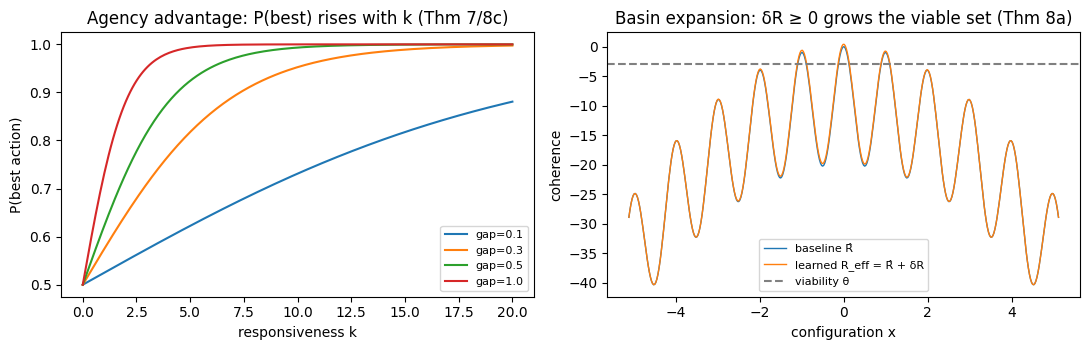

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ks = np.linspace(0, 20, 200)
for gap in (0.1, 0.3, 0.5, 1.0):
    ax[0].plot(ks, [boltzmann_prob_best(k, gap) for k in ks], label=f"gap={gap}")
ax[0].set(title="Agency advantage: P(best) rises with k (Thm 7/8c)",
          xlabel="responsiveness k", ylabel="P(best action)")
ax[0].legend(fontsize=8)

L = landscapes.rastrigin(1)
grid = np.linspace(L.lo[0], L.hi[0], 400)
base = np.array([L.coherence(np.array([g])) for g in grid])
ag = IBFLearner(L.coherence, L.lo, L.hi, alpha=0.5, mu=0.02, k=1.0, seed=3); ag.run(200)
reff = np.array([ag.R_eff(np.array([g])) for g in grid])
ax[1].plot(grid, base, label="baseline R̂", lw=1)
ax[1].plot(grid, reff, label="learned R_eff = R̂ + δR", lw=1)
ax[1].axhline(-3.0, ls="--", c="grey", label="viability θ")
ax[1].set(title="Basin expansion: δR ≥ 0 grows the viable set (Thm 8a)",
          xlabel="configuration x", ylabel="coherence")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Pilot 2 — Emergent Cooperation (Layer 2)

IBF agents play the iterated Prisoner's Dilemma. They sense only the immediate
own payoff (which favours defection), but their modification map accumulates the
**relational** coherence of mutual cooperation. Cooperation emerges *only* with
memory, and *only* when the relational coupling `J` is present (EC-4).

In [4]:
demo.pilot2(seeds=24)


  PILOT 2  -- Emergent Cooperation in the Iterated Prisoner's Dilemma (Layer 2)

[Cooperation emerges only with modification memory]
   IBF-memory vs IBF-memory : mutual cooperation (late) = 1.00   score = 3.00
   memoryless vs memoryless : mutual cooperation (late) = 0.00   score = 1.01   (defection trap)

[Behaviour against fixed strategies -- cooperates with reciprocators, defends vs defectors]
   IBF-memory vs AllD     : my cooperation (late) = 0.00   my score = 0.98
   IBF-memory vs TitForTat: my cooperation (late) = 1.00   my score = 3.00
   IBF-memory vs AllC     : my cooperation (late) = 1.00   my score = 3.00
   IBF-memory vs Pavlov   : my cooperation (late) = 1.00   my score = 3.00

[Causal test, EC-4]  relational coupling J -- not the optimism -- sustains it:


   J = 0.0 -> mutual cooperation = 0.04   (defection trap)


   J = 4.0 -> mutual cooperation = 1.00   (cooperation)

[Round-robin tournament]  mean score per round / cooperation rate:
   IBF-mem    score = 2.467   cooperation = 0.65
   TitForTat  score = 2.405   cooperation = 0.69
   Pavlov     score = 2.289   cooperation = 0.81
   AllC       score = 2.053   cooperation = 1.00
   IBF-none   score = 2.022   cooperation = 0.01
   AllD       score = 2.013   cooperation = 0.00
   Random     score = 1.787   cooperation = 0.47

[Evolutionary selection by differential persistence -- Thm 6 corollary]
   modification strength 1.0 -> survives 14 steps above threshold
   modification strength 2.0 -> survives 28 steps above threshold
   modification strength 4.0 -> survives 42 steps above threshold
   modification strength 8.0 -> survives 55 steps above threshold
   -> stronger memory persists longer under uniform decay (selection, no fitness fn)


Cooperation matrix — who cooperates with whom (round-robin):

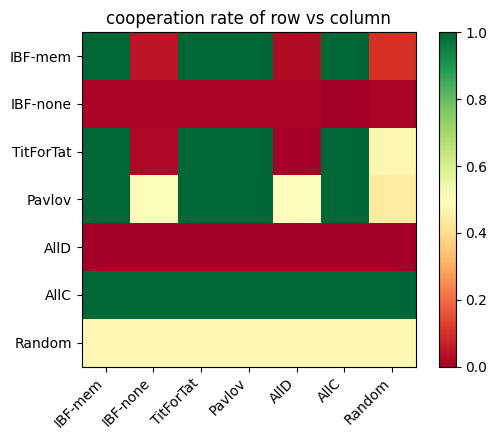

In [5]:
players = {
    "IBF-mem":  lambda: games.IBFGameAgent(seed=7),
    "IBF-none": lambda: games.IBFGameAgent(alpha=0.0, k=5.0, init_coop=0.0, seed=7),
    "TitForTat": games.TitForTat, "Pavlov": games.Pavlov,
    "AllD": games.AlwaysDefect, "AllC": games.AlwaysCooperate,
    "Random": lambda: games.RandomPlayer(seed=7),
}
t = games.round_robin(players, rounds=200)
labels = t["labels"]
M = np.array([[t["coop_matrix"][i][j] for j in labels] for i in labels])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_title("cooperation rate of row vs column"); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## Pilot 3 — Coarse-Graining, RG Flow & Hierarchy (Layer 3)

Renormalisation flow suppresses irrelevant small-scale noise (the relevant scale
emerges; the peak is non-increasing under coarsening). A hierarchical optimiser
that coarse-grains a block-structured landscape into independent sub-problems
beats a flat learner at equal evaluation budget.

In [6]:
demo.pilot3(seeds=8)


  PILOT 3  -- Coarse-Graining, Renormalisation Flow & Hierarchy (Layer 3)

[RG flow]  irrelevant small-scale noise is suppressed; the relevant scale emerges:
   level 0: size = 64   signal/noise = 1.20
   level 1: size = 32   signal/noise = 1.71
   level 2: size = 16   signal/noise = 3.57
   level 3: size =  8   signal/noise = 2.80
   level 4: size =  4   signal/noise = 1.66
   peak |field| per level = [1.82, 1.47, 1.08, 1.04, 0.62]  -> non-increasing under coarsening: True

[Hierarchy vs flat]  block-structured Rosenbrock, eval-budget matched, mean over 8 seeds:


   6 blocks x 2d = 12d :  hierarchical f =  0.364   flat f =  6.791   hierarchy wins 8/8


   4 blocks x 3d = 12d :  hierarchical f =  3.334   flat f =  5.268   hierarchy wins 5/8
   -> coarse-graining into independent sub-problems beats flat high-dim search.


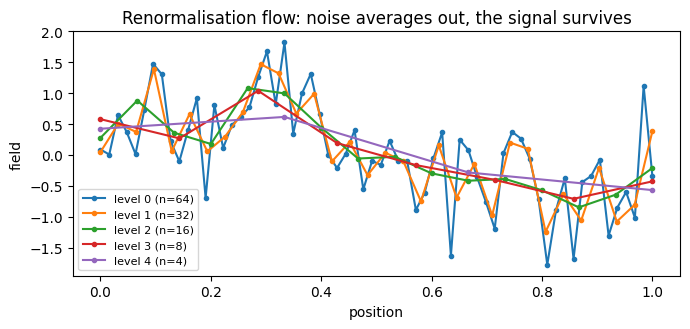

In [7]:
rng = np.random.default_rng(0)
n = 64
signal = np.sin(2*np.pi*np.linspace(0, 1, n))
field = signal + rng.normal(0, 0.7, n)
flow = hierarchy.rg_flow(field, factor=2, steps=4)
fig, ax = plt.subplots(figsize=(7, 3.4))
for i, f in enumerate(flow):
    ax.plot(np.linspace(0, 1, f.size), f, marker="o", ms=3, label=f"level {i} (n={f.size})")
ax.set(title="Renormalisation flow: noise averages out, the signal survives",
       xlabel="position", ylabel="field")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Pilot 4 — Bounded Self-Knowledge & the Phase Transition (Layer 3)

The Lawvere diagonal proves no self-model is surjective (perfect self-knowledge
is impossible); introspection depth is capped by capacity; consciousness has an
exact sub-/super-critical structure and a finite undriven lifetime; and a
self-monitoring agent outlasts a non-monitoring twin under adversarial shocks.

In [8]:
demo.pilot4()


  PILOT 4  -- Bounded Self-Knowledge & the Consciousness Phase Transition (Layer 3)

[Lawvere obstruction]  no self-model is surjective -- perfect self-knowledge is impossible:
   |S| =  3: the diagonal response escapes every self-model -> perfect self-knowledge possible: False
   |S| =  5: the diagonal response escapes every self-model -> perfect self-knowledge possible: False
   |S| = 10: the diagonal response escapes every self-model -> perfect self-knowledge possible: False
   |S| = 50: the diagonal response escapes every self-model -> perfect self-knowledge possible: False

[Self-knowledge ceiling]  achievable introspection depth = floor(Gamma / base_cost):
   Gamma = 10, base_cost = 3 -> max depth = 3
   Gamma = 10, base_cost = 2.5 -> max depth = 4
   Gamma = 7, base_cost = 4 -> max depth = 1

[Consciousness-competence tradeoff]  capacity spent on introspection is lost to the task:
   depth 0: self-budget  0  domain capacity 12  ############
   depth 1: self-budget  2  domain ca

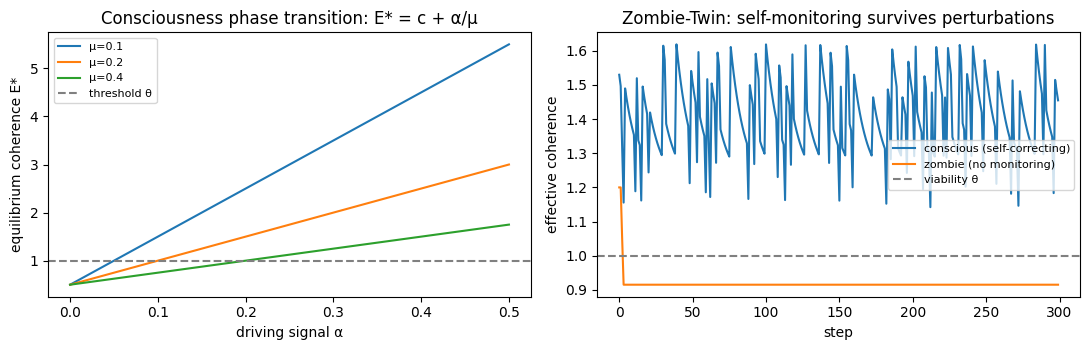

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

c, theta = 0.5, 1.0
for mu in (0.1, 0.2, 0.4):
    alphas = np.linspace(0, 0.5, 200)
    ax[0].plot(alphas, [phase.equilibrium_coherence(c, a, mu) for a in alphas], label=f"μ={mu}")
ax[0].axhline(theta, ls="--", c="grey", label="threshold θ")
ax[0].set(title="Consciousness phase transition: E* = c + α/μ",
          xlabel="driving signal α", ylabel="equilibrium coherence E*")
ax[0].legend(fontsize=8)

zt = phase.zombie_twin(seed=0)
ax[1].plot(zt["trace_conscious"], label="conscious (self-correcting)")
ax[1].plot(zt["trace_zombie"], label="zombie (no monitoring)")
ax[1].axhline(theta, ls="--", c="grey", label="viability θ")
ax[1].set(title="Zombie-Twin: self-monitoring survives perturbations",
          xlabel="step", ylabel="effective coherence")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## Full MSCN — all three layers at once

27 coupled coherence-gradient learners on a scale-free graph: they learn, reach
consensus (cooperation in state space), keep network coherence above the sum of
individual coherences, recover from periodic adversarial perturbations via
phase-controlled self-correction, and coarse-grain into a 27→9→3→1 hierarchy.

In [10]:
demo.mscn_demo()


  FULL MSCN  -- all three layers running at once



   27 coupled learners on Rastrigin-2D, scale-free graph, 120 rounds
   viability threshold theta = -1.394

   round | best | mean_eff | consensus | viable | event
       0 | -0.87 |  -13.475 |   3.355   | 27/27 | 
      20 | 1.48 |   -2.304 |   2.210   |  9/27 | 
      29 | 1.79 |   -1.500 |   2.099   | 13/27 | self-correct
      30 | 1.79 |   -2.477 |   1.569   | 11/27 | PERTURB
      33 | 2.78 |   -2.425 |   1.455   | 11/27 | self-correct
      59 | 3.45 |   -1.428 |   1.021   | 15/27 | self-correct
      60 | 3.45 |   -2.016 |   1.022   | 10/27 | PERTURB
      63 | 3.45 |   -2.039 |   1.111   |  8/27 | self-correct
      89 | 3.66 |   -1.500 |   0.981   | 14/27 | 
      90 | 3.66 |   -1.913 |   0.981   | 12/27 | PERTURB
      93 | 3.66 |   -1.580 |   1.010   | 13/27 | self-correct
     119 | 3.66 |   -1.349 |   1.076   | 17/27 | 

   learning      : best coherence -0.87 -> 3.66
   cooperation   : edge consensus 3.36 -> 1.08 (coupled agents align)
   coupling helps: network coheren

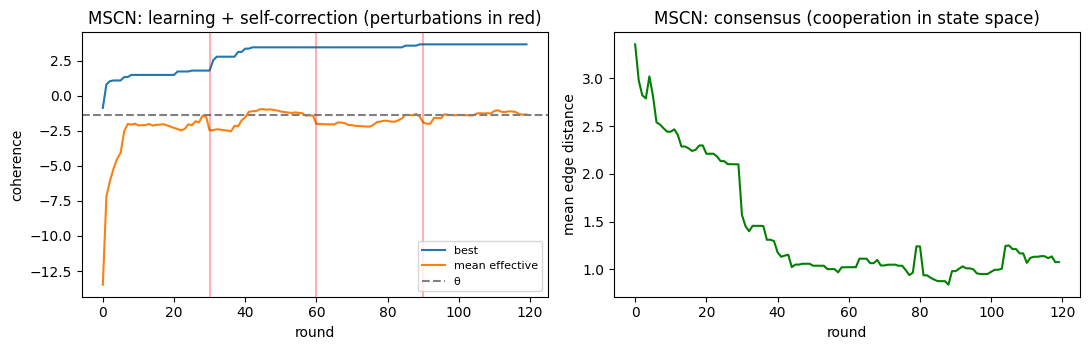

In [11]:
L = landscapes.rastrigin(2)
res = MSCN(L, MSCNConfig(n_agents=27, rounds=120, coupling_strength=0.4, perturb_every=30, seed=1)).run()
h = res["history"]; rounds = [r["round"] for r in h]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(rounds, [r["best_coherence"] for r in h], label="best")
ax[0].plot(rounds, [r["mean_coherence"] for r in h], label="mean effective")
ax[0].axhline(res["theta"], ls="--", c="grey", label="θ")
for r in h:
    if r["perturbed"]:
        ax[0].axvline(r["round"], c="red", alpha=0.3)
ax[0].set(title="MSCN: learning + self-correction (perturbations in red)",
          xlabel="round", ylabel="coherence"); ax[0].legend(fontsize=8)
ax[1].plot(rounds, [r["consensus"] for r in h], c="green")
ax[1].set(title="MSCN: consensus (cooperation in state space)",
          xlabel="round", ylabel="mean edge distance")
plt.tight_layout(); plt.show()

## Behavioural guarantee checks

Each check maps to a theorem in the formalisation. (The theorems themselves are
machine-checked in Lean; these keep the *implementation* honest.)

In [12]:
from mscn import tests as mscn_tests
mscn_tests.run()

running 24 guarantee checks

  PASS  test_basin_expansion_superset
  PASS  test_boltzmann_monotone_in_k
  PASS  test_competence_tradeoff_monotone


  PASS  test_cooperation_needs_coupling


  PASS  test_cooperation_requires_memory
  PASS  test_coupling_only_helps
  PASS  test_crystallization_constant
  PASS  test_defends_against_defectors
  PASS  test_differential_persistence
  PASS  test_discrete_basin_nonshrinking
  PASS  test_dissipative_lifetime
  PASS  test_euler_converges_to_ode
  PASS  test_forgetting_decays_to_zero


  PASS  test_hierarchy_beats_flat


  PASS  test_ibf_beats_random_highdim
  PASS  test_isolated_node_independent
  PASS  test_lawvere_no_surjective_self_model
  PASS  test_mean_field_suppression


  PASS  test_mscn_integration
  PASS  test_phase_transition
  PASS  test_rg_flow_suppresses_noise
  PASS  test_selective_retention
  PASS  test_self_knowledge_ceiling
  PASS  test_zombie_twin_survival

24 passed, 0 failed


0

## Takeaway

Implemented directly from the IBF dynamics — no neural networks, no
backpropagation — the toy model reproduces every qualitative behaviour the
framework proves: basin expansion, selective retention, agency, emergent
cooperation, multi-scale coarse-graining, bounded self-knowledge, and a
consciousness phase transition with self-correction. See `mscn/README.md` for
the architecture-to-code map and `python -m mscn.demo` / `python -m mscn.tests`
to run it from the command line.